# Analyze mental from IMDB 1 film Chapter 17 Wprkshop 1

## Load module

In [31]:
import numpy as np

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Embedding, Dense, Bidirectional

from tensorflow.keras.datasets import imdb

## Load datasets

In [3]:
import os
from pathlib import Path

# Find your Keras dataset cache
dataset_path = Path.home() / ".keras" / "datasets" / "imdb.npz"
if dataset_path.exists():
    dataset_path.unlink()  # Delete the file
    print("Corrupted imdb.npz deleted.")

Corrupted imdb.npz deleted.


In [4]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


In [5]:
print(X_train.shape, y_train.shape)
print('-'*50)
print(X_train[:3])
print('-'*50)
print(len(X_train[0]), len(X_train[1]), len(X_train[2]))
print('-'*50)

(25000,) (25000,)
--------------------------------------------------
[list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 11

## Check datasets

### train and test data

In [24]:
train_cls, train_count = np.unique(y_train, return_counts=True)
test_cls, test_count = np.unique(y_test, return_counts=True)
print("Training set classes and counts:")
print("Classes:", train_cls)
print("Counts:", train_count)
print("Test set classes and counts:")
print("Classes:", test_cls)
print("Counts:", test_count)


Training set classes and counts:
Classes: [0 1]
Counts: [12500 12500]
Test set classes and counts:
Classes: [0 1]
Counts: [12500 12500]
--------------------------------------------------
X_train shape: (25000, 250)
y_train shape: (25000,)
X_test shape: (25000, 250)
y_test shape: (25000,)


### decode data

In [7]:
index = imdb.get_word_index()
# Adjust the index to match the Keras version
reversed_index = {v: k for k, v in index.items()}
def decode_review(text):
    return ' '.join(reversed_index.get(i - 3, '#') for i in text)
print("Decoded review:", decode_review(X_train[0]))

Decoded review: # this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazi

### find min max mean of word count

In [8]:
data = np.concatenate((X_train, X_test), axis=0)
target = np.concatenate((y_train, y_test), axis=0)

word_num = np.unique(np.hstack(data))
cls_num = np.unique(target)
len_seq = [len(seq) for seq in data]
max_length = np.max(len_seq)
min_length = np.min(len_seq)
std_length = np.std(len_seq)
mean_length = np.mean(len_seq)

print("Number of unique words:", len(word_num))
print("Number of classes:", len(cls_num))
print("Mean length:", mean_length)
print("Max length:", max_length)
print("Min length:", min_length)
print("Std length:", std_length)


Number of unique words: 88585
Number of classes: 2
Mean length: 234.75892
Max length: 2494
Min length: 7
Std length: 172.91149458735703


### Plotting sentence length

In [9]:
import pandas as pd

df = pd.DataFrame(len_seq, columns=['length'])
df.describe().round(2)


,length
count,50000.00
mean,234.76
std,172.91
min,7.00
25%,129.00
50%,176.00
75%,285.00
max,2494.00


In [10]:
import matplotlib.pyplot as plt

#### plot with mine

(array([2.9690e+03, 1.0480e+04, 1.4532e+04, 7.2780e+03, 4.3490e+03,
        3.0110e+03, 1.9960e+03, 1.4430e+03, 1.0350e+03, 7.6200e+02,
        5.2900e+02, 4.3500e+02, 3.3000e+02, 2.4400e+02, 1.8800e+02,
        2.5400e+02, 1.2700e+02, 1.1000e+01, 4.0000e+00, 3.0000e+00,
        3.0000e+00, 1.0000e+00, 4.0000e+00, 0.0000e+00, 2.0000e+00,
        1.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([   7.   ,   69.175,  131.35 ,  193.525,  255.7  ,  317.875,
         380.05 ,  442.225,  504.4  ,  566.575,  628.75 ,  690.925,
         753.1  ,  815.275,  877.45 ,  939.625, 1001.8  , 1063.975,
        1126.15 , 1188.325, 1250.5  , 1312.675, 1374.85 , 1437.025,
        1499.2  , 1561.375, 1623.55 , 1685.725, 1747.9  , 1810.075,
        1872.25 , 1934.425, 1996.6  , 2058.775, 2120.95 , 2183.125,
        2245.3  , 2307.475, 2369.65 , 2431.825

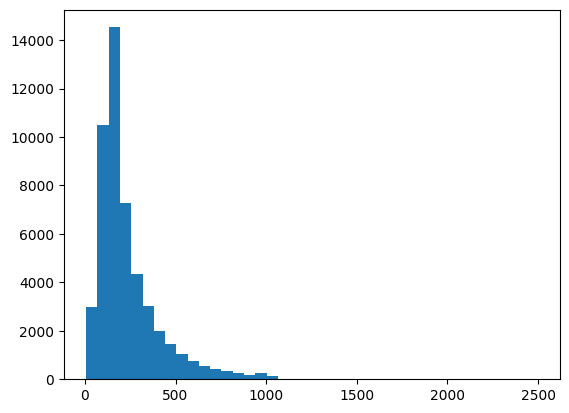

In [11]:
plt.hist(len_seq, bins=40)

#### plot from Co-pilot

In [12]:
# Group data in len_seq and count occurrences
length_counts = df['length'].value_counts().reset_index()
length_counts.columns = ['length', 'count']
length_counts = length_counts.sort_values(by='length').reset_index(drop=True)
print(length_counts)

      length  count
0          7      2
1          9      1
2         10      2
3         11      3
4         12      1
...      ...    ...
1055    1854      1
1056    2110      1
1057    2119      1
1058    2315      1
1059    2494      1

[1060 rows x 2 columns]


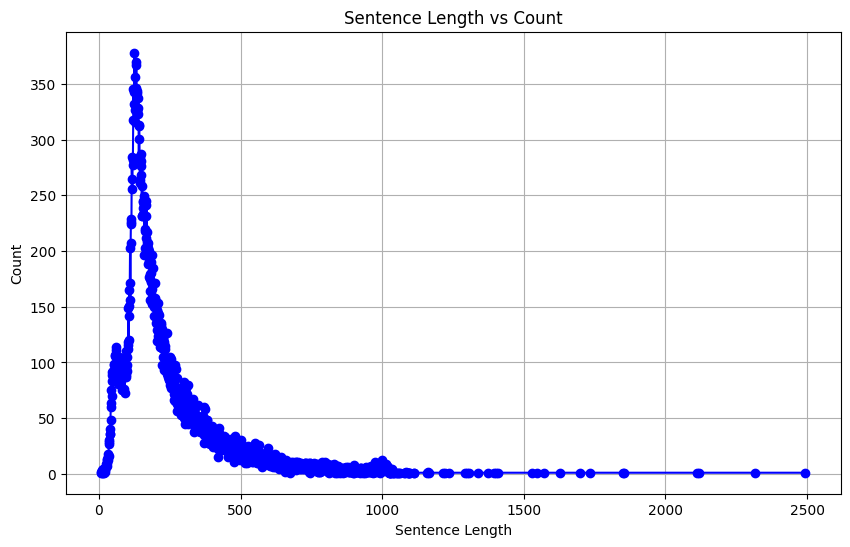

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(length_counts['length'], length_counts['count'], marker='o', linestyle='-', color='b')
plt.title('Sentence Length vs Count')
plt.xlabel('Sentence Length')
plt.ylabel('Count')
plt.grid(True)
plt.show()
del length_counts

## Prepare data

In [39]:
# sentence words for input to model
max_len = 250
embeded_size = 100
vocab_len = 90000

X_train = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

print("Padded X_train shape:", X_train.shape)

Padded X_train shape: (25000, 250)


In [41]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print(set(y_train))  # Should show {0, 1}
print(f'dtype of X_train: {X_train.dtype}')
print(f'dtype of y_train: {y_train.dtype}')
print(f'dtype of X_test: {X_test.dtype}')
print(f'dtype of y_test: {y_test.dtype}')

X_train shape: (25000, 250)
y_train shape: (25000,)
X_test shape: (25000, 250)
y_test shape: (25000,)
{0, 1}
dtype of X_train: int32
dtype of y_train: int64
dtype of X_test: int32
dtype of y_test: int64


## Create model

In [42]:
print(X_test[1].shape[0])

250


In [43]:
model = Sequential(name='imdb_model')
model.add(Embedding(input_dim=vocab_len, output_dim=embeded_size, input_length=(X_test[1].shape[0],), name='embedding_layer'))
# model.add(Embedding(input_dim=vocab_len, output_dim=embeded_size, input_shape=(X_test[1].shape[0],), name='embedding_layer'))
# model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(GRU(units=128, activation='tanh'), name='BiGRU_layer'))
model.add(Dense(1, activation='sigmoid', name='output_layer'))

model.build(input_shape=(None, X_test[1].shape[0]))
model.summary()

d:\Project\Learning\Environment_Project\tensorflow\tf-gpu-py310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "imdb_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 250, 100)       │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiGRU_layer (Bidirectional)     │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,176,897 (35.01 MB)

 Trainable params: 9,176,897 (35.01 MB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [44]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Train model

In [46]:
history = model.fit(X_train, y_train, epochs=5, batch_size=256, verbose=1, validation_data=(X_test, y_test))

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 75s 771ms/step - accuracy: 0.8738 - loss: 0.3156 - val_accuracy: 0.7491 - val_loss: 0.5174
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 773ms/step - accuracy: 0.9112 - loss: 0.2461 - val_accuracy: 0.8274 - val_loss: 0.4117
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 776ms/step - accuracy: 0.9564 - loss: 0.1390 - val_accuracy: 0.8270 - val_loss: 0.4712
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 773ms/step - accuracy: 0.9742 - loss: 0.0862 - val_accuracy: 0.8313 - val_loss: 0.5531
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 75s 772ms/step - accuracy: 0.9841 - loss: 0.0571 - val_accuracy: 0.8234 - val_loss: 0.6019


## Plot accuracy and loss curve

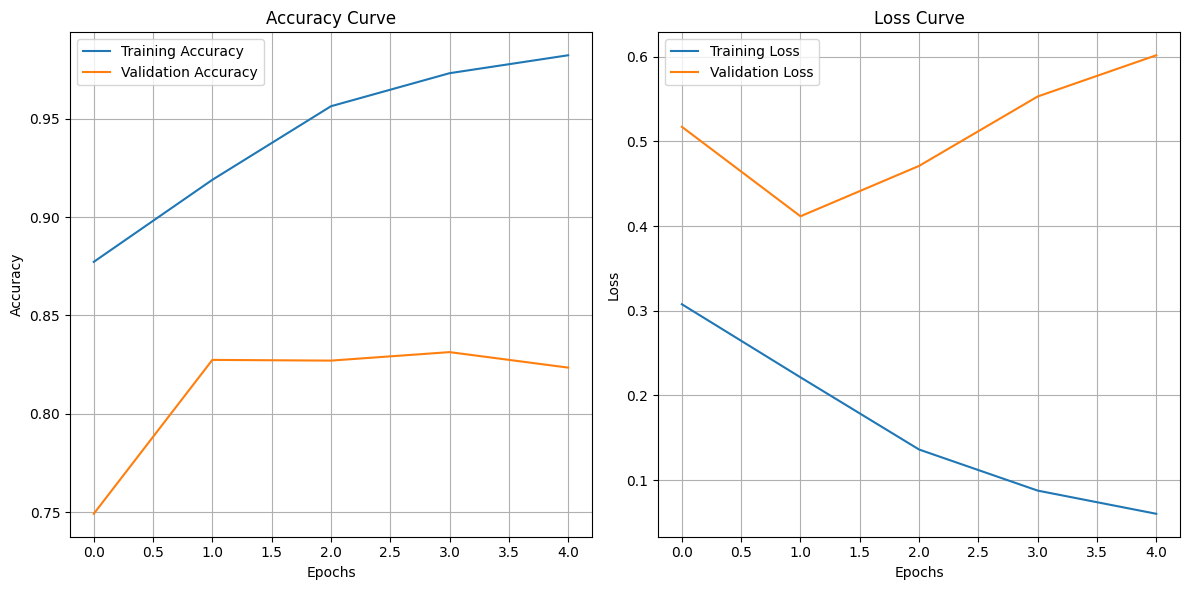

In [48]:
# Extract accuracy and loss values from the history object
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot accuracy and loss curves
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Save model

In [47]:
import os
model_path = r'../models/ws1701/imdb_review_model.h5'
if not os.path.exists(os.path.dirname(model_path)):
    print('Unable to save model, directory does not exist:', os.path.dirname(model_path))
else:
    if os.path.exists(model_path):
        print('Already exists, deleting:', model_path)
    else:
        model.save(model_path)
        print('Saving model to:', model_path)

Saving model to: ../models/ws1701/imdb_review_model.h5


## Prediction

In [63]:
# pred_data = np.expand_dims(X_test[:10], axis=0)
pred_data = X_test[:10]  # Use the first 10 samples for prediction 
print("Shape of X_test[0]:", pred_data.shape)
predictions = model.predict(pred_data)


Shape of X_test[0]: (10, 250)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


## Check result 

In [66]:
show_index = 9
print("Decoded review:", decode_review(X_test[show_index]))
print(f'pred: {predictions[show_index]}')  # Display the first 10 predictions
print(f'actual: {y_test[show_index]}')  # Display the actual label for the first test sample

Decoded review: # this film is where the batman franchise ought to have stopped though i will concede that the ideas behind batman forever were excellent and could have been easily realised by a competent director as it turned out this was not to be the case br br apparently warner brothers executives were disappointed with how dark this second batman film from tim burton turned out apart from the idiocy of expecting anything else from burton and the conservative cowardice of their subsequent decision to turn the franchise into an homage to the sixties tv series i fail to understand how batman returns can be considered at all disappointing br br true it is not quite the equal of the first film though it repairs all the minor deficiencies of style found in batman a weaker script that splits the antagonism between not just two but three characters invites unflattering comparisons to the masterful pairing of keaton and jack nicholson as the joker in the first film yet for all this it rema

In [78]:
X_test[:2].shape

(2, 250)